# Bank Customer Churn Prediction - V1.1 (XGBoost - Recall Optimized)

This notebook builds a comprehensive machine learning model to predict customer churn for a bank. It is based on a robust classification template, adapted for the specific challenges and features of this dataset.

**Goal:** Predict "which customers are most likely to churn?" (`Exited` = 1), with a primary focus on maximizing **Recall** to ensure we identify as many potential churners as possible.

**Key Features of this Model:**
*   **Model:** Uses XGBoost, a powerful gradient boosting algorithm known for high performance.
*   **Primary Metric:** The model is tuned and evaluated based on **Recall**, which is critical for churn prediction to minimize missed opportunities for retention.
*   **Feature Engineering:** Based on our initial analysis, several new features are created to capture complex customer behaviors:
    *   `TenureToAgeRatio`: To identify long-term, loyal customers.
    *   `BalanceToSalaryRatio`: A measure of a customer's financial health/savings rate.
    *   `PointsPerTenure`: An engagement metric for credit card usage over time.
    *   `IsTransactionalCustomer`: A flag for customers with low balances but active credit cards.
    *   `ComplaintResolved`: An interaction feature to see if resolving a complaint impacts retention.
*   **Imbalance Handling:** The model is tuned using `scale_pos_weight` in XGBoost, a direct and effective method for handling class imbalance.
*   **Rigorous Evaluation:** Includes extensive overfitting analysis using learning curves, validation curves, and detailed classification reports, all focused on the `recall` metric.

*   **Data Leak check / test:** First time running v1 end up showing data leak on the column "complain" where the model was getting basicaly 100% on all scores, we drop that column and others relate to complain on v1.1

## 1. Setup - Import Libraries

In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve, validation_curve, cross_val_predict
from sklearn.preprocessing import LabelEncoder
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import recall_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score, make_scorer
import io

# Import Colab specific tools for file handling
from google.colab import files

# Ignore minor warnings for cleaner output
warnings.filterwarnings('ignore')
# Display options for pandas
pd.set_option('display.max_columns', None) # Show all columns

print("Libraries imported successfully.")

Libraries imported successfully.


### Install Required Libraries (if not already present)

In [ ]:
!pip install -U xgboost
print("xgboost check/installation complete.")

xgboost check/installation complete.


## 2. Load Data

Upload the `Customer-Churn-Records.csv` file.

In [ ]:
print("Please upload Customer-Churn-Records.csv:")
uploaded_file = files.upload()

# Load File into DataFrame
try:
    filename = list(uploaded_file.keys())[0]
    full_df = pd.read_csv(io.BytesIO(uploaded_file[filename]))
    print("Successfully loaded the dataset.")
    print(f"Dataset shape: {full_df.shape}")
    print("\nData Head:")
    display(full_df.head())
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please ensure you uploaded the correct CSV file.")

Please upload Customer-Churn-Records.csv:


Saving Customer-Churn-Records.csv to Customer-Churn-Records.csv
Successfully loaded the dataset.
Dataset shape: (10000, 18)

Data Head:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


## 3. Feature Engineering & Preprocessing

This section prepares the data by creating new features based on our initial hypotheses and converting the data into a model-ready format.

### 3.1 Drop Unnecessary Columns & Create New Features

In [ ]:
# --- 3.1 Drop Unnecessary/Leaky Columns & Create New Features ---

print("--- Starting Feature Engineering & Preprocessing ---")

# Step 1: Drop Identifier and Leaky Columns
# We remove identifiers and the columns identified as causing data leakage.
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname', 'Complain', 'Satisfaction Score', 'Point Earned']
df = full_df.drop(columns=columns_to_drop)
print(f"Dropped unnecessary and leaky columns: {columns_to_drop}")


# Step 2: Create New, Non-Leaky Features
print("\nCreating new features based on our hypotheses...")

# Handle potential division by zero by adding a small epsilon (1e-6)
# A customer's loyalty might be related to how long they've been with the bank relative to their age.
df['TenureToAgeRatio'] = df['Tenure'] / (df['Age'] + 1e-6)

# Ratio of balance to salary might indicate financial health or savings habits.
df['BalanceToSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1e-6)

# Flag for customers who might only be using the bank for credit card services.
df['IsTransactionalCustomer'] = ((df['Balance'] == 0) & (df['HasCrCard'] == 1)).astype(int)

# Binning CreditScore can help the model capture non-linear relationships.
# Turning a continuous variable into categorical groups.
score_bins = [0, 580, 670, 740, 851]
score_labels = ['Poor', 'Fair', 'Good', 'Excellent']
df['CreditScoreTier'] = pd.cut(df['CreditScore'], bins=score_bins, labels=score_labels, right=False)

print("New features created: 'TenureToAgeRatio', 'BalanceToSalaryRatio', 'IsTransactionalCustomer', 'CreditScoreTier'")

# Display a sample of the new features to verify
print("\nDataFrame head after feature creation:")
display(df[['Age', 'Tenure', 'TenureToAgeRatio', 'Balance', 'EstimatedSalary', 'BalanceToSalaryRatio', 'IsTransactionalCustomer', 'CreditScore', 'CreditScoreTier']].head())

print("\nValue counts for new 'CreditScoreTier' feature:")
print(df['CreditScoreTier'].value_counts())

# The original dataframe 'full_df' is now replaced by our cleaned and engineered 'df'
full_df = df
print("\n--- Section 3.1 Complete ---")

--- Starting Feature Engineering & Preprocessing ---
Dropped unnecessary and leaky columns: ['RowNumber', 'CustomerId', 'Surname', 'Complain', 'Satisfaction Score', 'Point Earned']

Creating new features based on our hypotheses...
New features created: 'TenureToAgeRatio', 'BalanceToSalaryRatio', 'IsTransactionalCustomer', 'CreditScoreTier'

DataFrame head after feature creation:


,Age,Tenure,TenureToAgeRatio,Balance,EstimatedSalary,BalanceToSalaryRatio,IsTransactionalCustomer,CreditScore,CreditScoreTier
0,42,2,0.047619,0.00,101348.88,0.000000,1,619,Fair
1,41,1,0.024390,83807.86,112542.58,0.744677,0,608,Fair
2,42,8,0.190476,159660.80,113931.57,1.401375,0,502,Poor
3,39,1,0.025641,0.00,93826.63,0.000000,0,699,Good
4,43,2,0.046512,125510.82,79084.10,1.587055,0,850,Excellent



Value counts for new 'CreditScoreTier' feature:
CreditScoreTier
Fair         3331
Good         2428
Poor         2362
Excellent    1879
Name: count, dtype: int64

--- Section 3.1 Complete ---


### 3.2 Convert Categorical Features

In [ ]:
# --- One-Hot Encode Nominal Features ---
cols_to_encode = ['Geography', 'Gender', 'Card Type', 'CreditScoreTier']
print(f"One-Hot Encoding: {cols_to_encode}...")

processed_df = pd.get_dummies(full_df, columns=cols_to_encode, drop_first=True)

print("\nDataFrame head after categorical conversion:")
display(processed_df.head())
print("\nPreprocessing complete. Final features:")
print(processed_df.columns)

One-Hot Encoding: ['Geography', 'Gender', 'Card Type', 'CreditScoreTier']...

DataFrame head after categorical conversion:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,TenureToAgeRatio,BalanceToSalaryRatio,IsTransactionalCustomer,Geography_Germany,Geography_Spain,Gender_Male,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER,CreditScoreTier_Fair,CreditScoreTier_Good,CreditScoreTier_Excellent
0,619,42,2,0.00,1,1,1,101348.88,1,0.047619,0.000000,1,False,False,False,False,False,False,True,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,0.024390,0.744677,0,False,True,False,False,False,False,True,False,False
2,502,42,8,159660.80,3,1,0,113931.57,1,0.190476,1.401375,0,False,False,False,False,False,False,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,0.025641,0.000000,0,False,False,False,True,False,False,False,True,False
4,850,43,2,125510.82,1,1,1,79084.10,0,0.046512,1.587055,0,False,True,False,True,False,False,False,False,True



Preprocessing complete. Final features:
Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'TenureToAgeRatio',
       'BalanceToSalaryRatio', 'IsTransactionalCustomer', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male', 'Card Type_GOLD',
       'Card Type_PLATINUM', 'Card Type_SILVER', 'CreditScoreTier_Fair',
       'CreditScoreTier_Good', 'CreditScoreTier_Excellent'],
      dtype='object')


## 4. Split Data into Training and Test Sets

In [ ]:
X = processed_df.drop('Exited', axis=1)
y = processed_df['Exited']

# Using Stratified Split to maintain the same proportion of churners in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features shape: {X_train.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"Test target shape: {y_test.shape}")

Training features shape: (8000, 20)
Training target shape: (8000,)
Test features shape: (2000, 20)
Test target shape: (2000,)


## 5. Check Target Variable Distribution (Imbalance)

Distribution of target variable 'Exited' in y_train:
Exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64


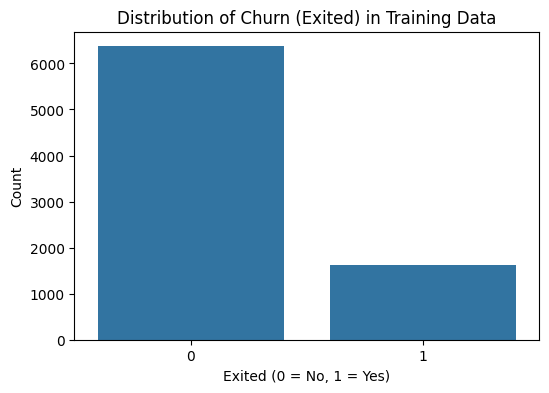


Calculated scale_pos_weight for XGBoost to handle imbalance: 3.91


In [ ]:
print("Distribution of target variable 'Exited' in y_train:")
churn_distribution = y_train.value_counts(normalize=True)
print(churn_distribution)

plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title('Distribution of Churn (Exited) in Training Data')
plt.xlabel('Exited (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Calculate scale_pos_weight for XGBoost
scale_pos_weight = churn_distribution[0] / churn_distribution[1]
print(f"\nCalculated scale_pos_weight for XGBoost to handle imbalance: {scale_pos_weight:.2f}")

## 6. Hyperparameter Tuning & Model Training (XGBoost)

Using `GridSearchCV` with **`recall`** as the primary scoring metric. We will also include `scale_pos_weight` in our grid search to let the model find the optimal weight for handling the class imbalance.

In [ ]:
print("\nSetting up GridSearchCV for XGBoost (Optimizing for Recall)...")

xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# A focused parameter grid for V1. Can be expanded for more exhaustive search.
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'gamma': [0, 0.1],
    # Let's tune scale_pos_weight around the calculated value
    'scale_pos_weight': [scale_pos_weight, scale_pos_weight * 0.8, scale_pos_weight * 1.2]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(estimator=xgb_model,
                           param_grid=param_grid,
                           cv=cv_strategy,
                           scoring='recall', # PRIMARY METRIC
                           n_jobs=-1, # Use all available cores
                           verbose=2)

print("Starting GridSearchCV... This may take several minutes.")
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("\nGridSearchCV Complete.")
print(f"Best Cross-Validation Recall Score found: {grid_search.best_score_:.4f}")
print("Best Parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

# Evaluate on the full training set using the best model
y_train_pred_best_model = best_model.predict(X_train)
train_recall_best_model = recall_score(y_train, y_train_pred_best_model)
print(f"\nRecall of the best model on the *entire* training set: {train_recall_best_model:.4f}")

print("\nTop 15 Feature Importances from the best XGBoost model:")
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(importances.head(15))


Setting up GridSearchCV for XGBoost (Optimizing for Recall)...
Starting GridSearchCV... This may take several minutes.
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

GridSearchCV Complete.
Best Cross-Validation Recall Score found: 0.7914
Best Parameters found:
  colsample_bytree: 0.7
  gamma: 0.1
  learning_rate: 0.1
  max_depth: 3
  n_estimators: 100
  scale_pos_weight: 4.68957055214724
  subsample: 0.7

Recall of the best model on the *entire* training set: 0.8233

Top 15 Feature Importances from the best XGBoost model:
                    Feature  Importance
4             NumOfProducts    0.189620
1                       Age    0.177369
6            IsActiveMember    0.119673
11        Geography_Germany    0.088346
13              Gender_Male    0.060801
3                   Balance    0.055755
9      BalanceToSalaryRatio    0.050826
10  IsTransactionalCustomer    0.046136
15       Card Type_PLATINUM    0.032529
14           Card Type_GOLD    0.027829
8          Te

## 7. Overfitting Analysis (Using Best XGBoost & Recall)

Now, we'll analyze the best model for signs of overfitting. Our primary metric of concern is **Recall**.

### 7.1 Training vs. Cross-Validation Recall

In [ ]:
print("\n--- 1. Training vs. Cross-Validation Recall ---")
cv_recall = grid_search.best_score_

print(f"Recall on FULL Training Set (using best model): {train_recall_best_model:.4f}")
print(f"Best Mean Cross-Validation Recall: {cv_recall:.4f}")
print(f"Difference (Train Recall - CV Recall): {train_recall_best_model - cv_recall:.4f}")

if (train_recall_best_model - cv_recall) > 0.10: # Recall can have higher variance, so a slightly larger threshold
    print("\nWarning: Potential overfitting detected! Training Recall is notably higher than CV Recall.")
else:
    print("\nTraining and CV Recall are reasonably close. Lower risk of significant overfitting.")


--- 1. Training vs. Cross-Validation Recall ---
Recall on FULL Training Set (using best model): 0.8233
Best Mean Cross-Validation Recall: 0.7914
Difference (Train Recall - CV Recall): 0.0319

Training and CV Recall are reasonably close. Lower risk of significant overfitting.


### 7.2 Learning Curves (Recall)


--- 2. Generating Learning Curves (Recall) ---


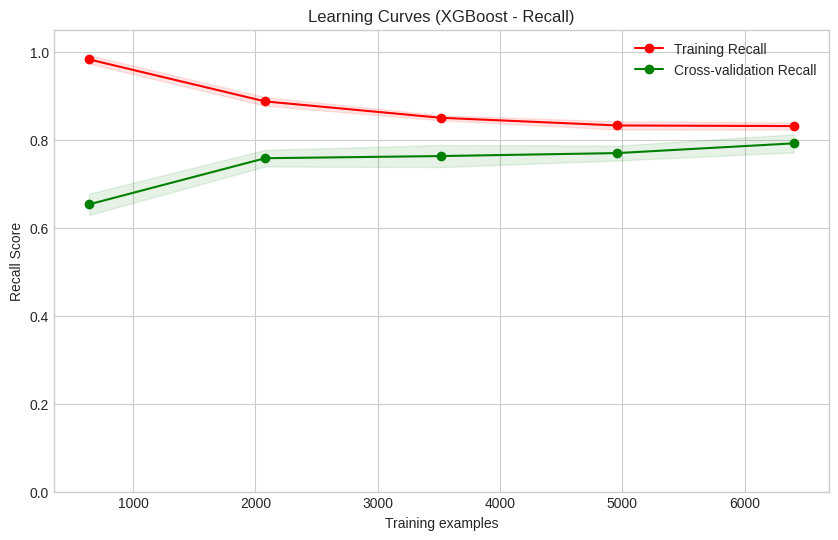

Observe the gap and convergence of training and cross-validation recall curves.


In [ ]:
print("\n--- 2. Generating Learning Curves (Recall) ---")
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=best_model,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1,
    random_state=42
)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)
validation_scores_std = np.std(validation_scores, axis=1)

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, validation_scores_mean - validation_scores_std, validation_scores_mean + validation_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Recall")
plt.plot(train_sizes, validation_scores_mean, 'o-', color="g", label="Cross-validation Recall")
plt.title("Learning Curves (XGBoost - Recall)")
plt.xlabel("Training examples")
plt.ylabel("Recall Score")
plt.legend(loc="best")
plt.grid(True)
plt.ylim(0.0, 1.05)
plt.show()
print("Observe the gap and convergence of training and cross-validation recall curves.")

### 7.2.1 Validation Curve (Max-depth(Recall))


--- 7.3 Generating Validation Curve for 'max_depth' (Recall) ---


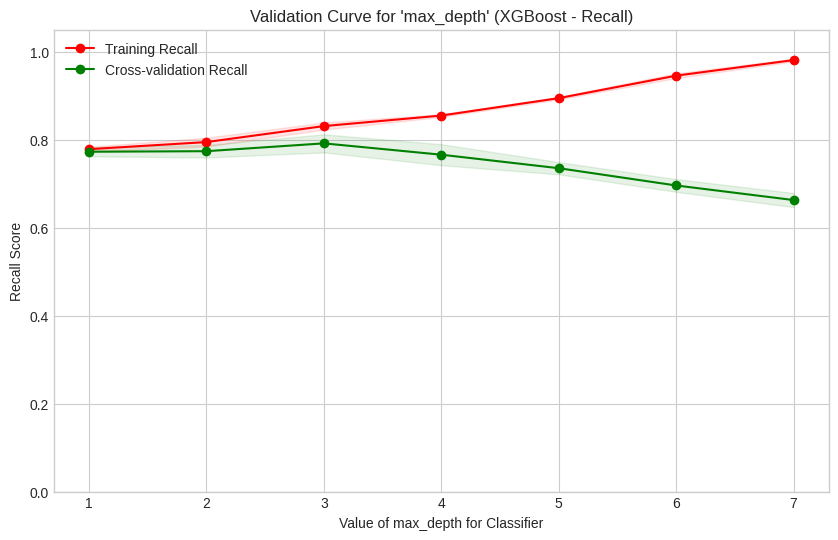

Validation curve plot generated.
This plot helps visualize how model complexity (max_depth) affects performance and overfitting.


In [ ]:
print("\n--- 7.3 Generating Validation Curve for 'max_depth' (Recall) ---")

# Parameter to vary.
param_name_vc = 'max_depth'
param_range_vc = np.arange(1, 8, 1) # A reasonable range for max_depth

# Create a base estimator with all other best parameters fixed.
# This isolates the effect of the parameter we are varying.
base_params_for_vc = grid_search.best_params_.copy()
if param_name_vc in base_params_for_vc:
    del base_params_for_vc[param_name_vc] # Remove the param we are varying from the fixed set

estimator_for_vc = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', **base_params_for_vc)

try:
    # Calculate scores for the validation curve
    train_scores_vc, validation_scores_vc = validation_curve(
        estimator=estimator_for_vc,
        X=X_train,
        y=y_train,
        param_name=param_name_vc,
        param_range=param_range_vc,
        cv=cv_strategy,
        scoring="recall", # Our primary metric
        n_jobs=-1
    )

    # Calculate mean and standard deviation for plotting
    train_mean_vc = np.mean(train_scores_vc, axis=1)
    train_std_vc = np.std(train_scores_vc, axis=1)
    valid_mean_vc = np.mean(validation_scores_vc, axis=1)
    valid_std_vc = np.std(validation_scores_vc, axis=1)

    # Plot the validation curve
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(10, 6))
    plt.plot(param_range_vc, train_mean_vc, 'o-', color='r', label='Training Recall')
    plt.fill_between(param_range_vc, train_mean_vc - train_std_vc, train_mean_vc + train_std_vc, alpha=0.1, color='r')
    plt.plot(param_range_vc, valid_mean_vc, 'o-', color='g', label='Cross-validation Recall')
    plt.fill_between(param_range_vc, valid_mean_vc - valid_std_vc, valid_mean_vc + valid_std_vc, alpha=0.1, color='g')

    plt.title(f"Validation Curve for '{param_name_vc}' (XGBoost - Recall)")
    plt.xlabel(f"Value of {param_name_vc} for Classifier")
    plt.ylabel("Recall Score")
    plt.legend(loc='best')
    plt.grid(True)
    plt.xticks(param_range_vc)
    plt.ylim(0.0, 1.05) # Full range for recall
    plt.show()
    print("Validation curve plot generated.")
    print("This plot helps visualize how model complexity (max_depth) affects performance and overfitting.")

except Exception as e:
    print(f"Could not generate validation curve for {param_name_vc}: {e}")
    print("This might happen if the parameter range is invalid or conflicts with other fixed parameters.")

### 7.3 Classification Reports & Confusion Matrices


--- 3. Classification Reports & Confusion Matrices ---

Classification Report (Full Training Set - Best Model Predictions):
              precision    recall  f1-score   support

           0       0.95      0.79      0.86      6370
           1       0.50      0.82      0.62      1630

    accuracy                           0.80      8000
   macro avg       0.72      0.81      0.74      8000
weighted avg       0.85      0.80      0.81      8000

Generated cross-validated class predictions.

Classification Report (Cross-Validated Predictions on Train Set):
              precision    recall  f1-score   support

           0       0.94      0.78      0.85      6370
           1       0.48      0.79      0.60      1630

    accuracy                           0.78      8000
   macro avg       0.71      0.79      0.72      8000
weighted avg       0.84      0.78      0.80      8000



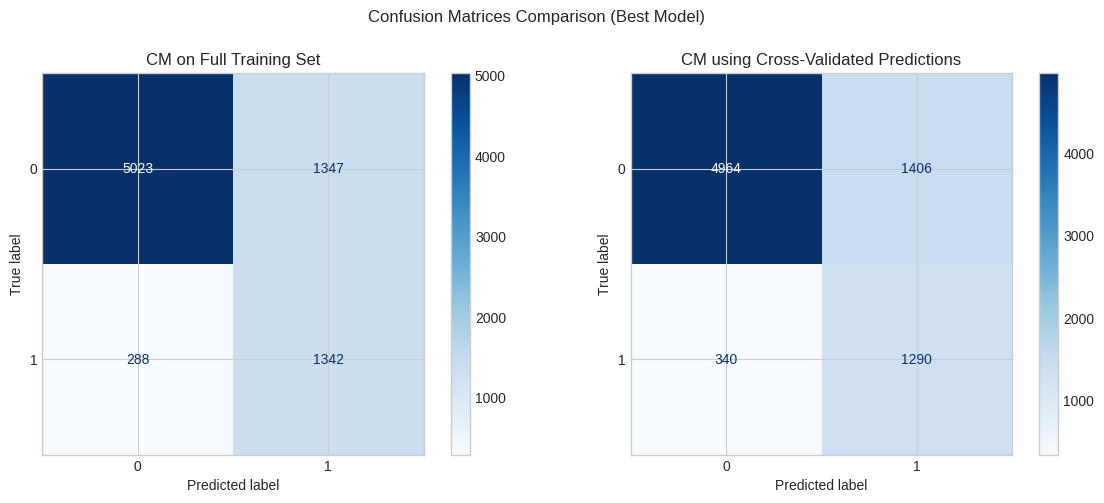

In [ ]:
print("\n--- 3. Classification Reports & Confusion Matrices ---")

print("\nClassification Report (Full Training Set - Best Model Predictions):")
print(classification_report(y_train, y_train_pred_best_model, zero_division=0))

try:
    y_train_cv_pred_class = cross_val_predict(best_model, X_train, y_train, cv=cv_strategy, n_jobs=-1)
    print("Generated cross-validated class predictions.")

    print("\nClassification Report (Cross-Validated Predictions on Train Set):")
    print(classification_report(y_train, y_train_cv_pred_class, zero_division=0))

    # Confusion Matrices
    cm_train = confusion_matrix(y_train, y_train_pred_best_model)
    cm_cv = confusion_matrix(y_train, y_train_cv_pred_class)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Confusion Matrices Comparison (Best Model)')

    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=best_model.classes_)
    disp_train.plot(ax=axes[0], cmap=plt.cm.Blues)
    axes[0].set_title('CM on Full Training Set')

    disp_cv = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=best_model.classes_)
    disp_cv.plot(ax=axes[1], cmap=plt.cm.Blues)
    axes[1].set_title('CM using Cross-Validated Predictions')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

except Exception as e:
    print(f"Could not generate cross-validated reports or matrices: {e}")

## 8. Final Evaluation on Test Set

This is the final step. We use the `best_model` trained on the full training data to make predictions on the unseen test data (`X_test`). This gives us the most realistic estimate of the model's performance in a real-world scenario.


Making predictions on the held-out test set...
--- Final Model Evaluation on Test Set ---
Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.94      0.77      0.85      1592
           1       0.47      0.81      0.60       408

    accuracy                           0.78      2000
   macro avg       0.71      0.79      0.72      2000
weighted avg       0.84      0.78      0.79      2000

Confusion Matrix (Test Set):


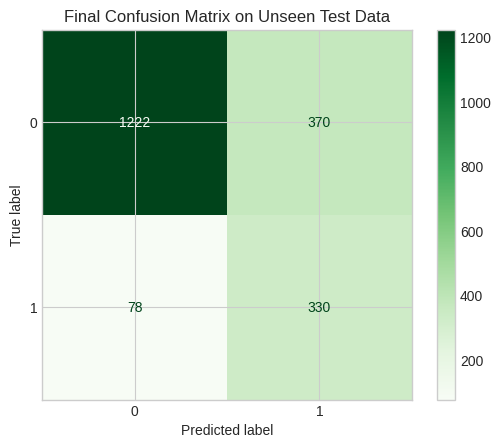

Final Recall on Test Set: 0.8088
Final Accuracy on Test Set: 0.7760

--- Churn Prediction Process Finished --- 


In [ ]:
print("\nMaking predictions on the held-out test set...")
y_pred_test = best_model.predict(X_test)

print("--- Final Model Evaluation on Test Set ---")
print("Classification Report (Test Set):")
print(classification_report(y_test, y_pred_test, zero_division=0))

print("Confusion Matrix (Test Set):")
cm_test = confusion_matrix(y_test, y_pred_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=best_model.classes_)
disp_test.plot(cmap=plt.cm.Greens)
plt.title('Final Confusion Matrix on Unseen Test Data')
plt.show()

final_recall = recall_score(y_test, y_pred_test)
final_accuracy = accuracy_score(y_test, y_pred_test)
print(f"Final Recall on Test Set: {final_recall:.4f}")
print(f"Final Accuracy on Test Set: {final_accuracy:.4f}")

print("\n--- Churn Prediction Process Finished --- ")